# T-NET 3-D Image Reconstruction with DCT + Wavelet Dictionaries

**Elastic Net sparse recovery of an RGB scene using overcomplete tensor dictionaries.**

This notebook demonstrates the **Tensor Elastic NET (T-NET)** algorithm from the `tensor_ml`
library applied to **3-D image reconstruction**.  A synthetic RGB scene is treated as an
order-3 tensor ($\text{rows} \times \text{cols} \times 3$) and reconstructed using
overcomplete dictionaries that combine a **DCT basis** with a **Symlet-4 wavelet packet basis**.

T-NET extends T-LARS with an **Elastic Net (L1 + L2)** penalty controlled by `lambda2`:

$$\min_x \|y - Ax\|_2^2 + \lambda_1 \|x\|_1 + \lambda_2 \|x\|_2^2$$

### Dictionary design

| Mode | Dictionary | Size | Description |
|------|-----------|------|-------------|
| **Rows** ($D_1$) | DCT ∪ WP(sym4,3) | $M \times 2M$ | Overcomplete (2×) |
| **Columns** ($D_2$) | DCT ∪ WP(sym4,3) | $N \times 2N$ | Overcomplete (2×) |
| **Channels** ($D_3$) | Identity | $3 \times 3$ | No overcompleteness |

### What you will see

| Step | Description |
|------|-------------|
| **1** | Generate a synthetic RGB scene (64×64×3) |
| **2** | Build DCT + Symlet-4 wavelet packet overcomplete dictionaries |
| **3** | Run T-NET and watch the 3-D reconstruction emerge |
| **4** | Convergence curves, coefficient paths, and quality metrics |
| **5** | Effect of `lambda2` on sparsity and reconstruction quality |
| **6** | T-NET vs T-LARS side-by-side comparison |
| **7** | Denoising with T-NET |

> **Requirements:** `numpy`, `matplotlib`, `scipy`, `PyWavelets`, `Pillow`, `tensor_ml`.

## 1. Install and Import Dependencies

In [1]:
# Uncomment if running for the first time:
# %pip install -e ../..   # install tensor_ml from repo root
# %pip install matplotlib scipy PyWavelets Pillow

import logging
import sys
import time
from typing import List

import numpy as np
import matplotlib.pyplot as plt
import pywt
from PIL import Image, ImageDraw, ImageFilter
from IPython import display as ipy_display

from tensor_ml import TNET, TLARS
from tensor_ml.tensor_models.multilinear.tnet import TNETConfig

print("All imports successful ✓")

All imports successful ✓


## 2. Configure Logging

In [2]:
tnet_logger = logging.getLogger("tensor_ml.tensor_models.multilinear.tnet")
tnet_logger.handlers.clear()

handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.DEBUG)
formatter = logging.Formatter(
    "%(asctime)s | %(levelname)-5s | %(message)s", datefmt="%H:%M:%S"
)
handler.setFormatter(formatter)
tnet_logger.addHandler(handler)
tnet_logger.setLevel(logging.DEBUG)

print("Logger configured — DEBUG messages will appear below each TNET run.")

Logger configured — DEBUG messages will appear below each TNET run.


## 3. Generate a Synthetic RGB Scene

Image tensor shape : (64, 64, 3)
Value range        : [0.000, 1.000]


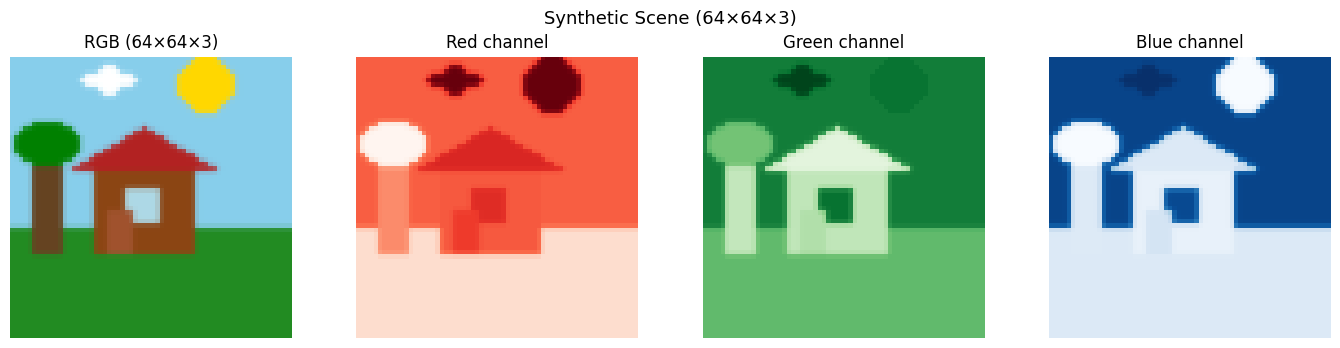

In [3]:
def make_scene_image(size: int = 64) -> np.ndarray:
    """Generate a colorful synthetic scene with geometric shapes."""
    img = Image.new("RGB", (size, size), (135, 206, 235))
    draw = ImageDraw.Draw(img)
    s = size

    draw.rectangle([0, int(0.62 * s), s, s], fill=(34, 139, 34))

    sx, sy, sr = int(0.7 * s), int(0.1 * s), int(0.1 * s)
    draw.ellipse([sx - sr, sy - sr, sx + sr, sy + sr], fill=(255, 215, 0))

    hx1, hy1, hx2, hy2 = int(0.3 * s), int(0.4 * s), int(0.65 * s), int(0.7 * s)
    draw.rectangle([hx1, hy1, hx2, hy2], fill=(139, 69, 19))
    mid_x = (hx1 + hx2) // 2
    draw.polygon([(hx1 - 5, hy1), (mid_x, int(0.25 * s)), (hx2 + 5, hy1)], fill=(178, 34, 34))
    draw.rectangle([int(0.42 * s), int(0.48 * s), int(0.53 * s), int(0.58 * s)], fill=(173, 216, 230))
    draw.rectangle([int(0.35 * s), int(0.55 * s), int(0.43 * s), int(0.7 * s)], fill=(160, 82, 45))

    tx1, ty1, tx2, ty2 = int(0.08 * s), int(0.35 * s), int(0.18 * s), int(0.7 * s)
    draw.rectangle([tx1, ty1, tx2, ty2], fill=(101, 67, 33))
    tr = int(0.12 * s)
    tc = (tx1 + tx2) // 2
    draw.ellipse([tc - tr, ty1 - tr, tc + tr, ty1 + int(0.3 * tr)], fill=(0, 128, 0))

    cx, cy, cr = int(0.35 * s), int(0.08 * s), int(0.06 * s)
    draw.ellipse([cx - cr, cy - cr, cx + cr, cy + cr], fill=(255, 255, 255))
    draw.ellipse([cx - 2 * cr, cy - cr // 2, cx, cy + cr // 2], fill=(255, 255, 255))
    draw.ellipse([cx, cy - cr // 2, cx + 2 * cr, cy + cr // 2], fill=(255, 255, 255))

    img = img.filter(ImageFilter.GaussianBlur(0.5))
    return np.asarray(img, dtype=np.float64) / 255.0


IMG_SIZE = 64
Y_image = make_scene_image(IMG_SIZE)

print(f"Image tensor shape : {Y_image.shape}")
print(f"Value range        : [{Y_image.min():.3f}, {Y_image.max():.3f}]")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(Y_image)
axes[0].set_title(f"RGB ({IMG_SIZE}×{IMG_SIZE}×3)")
axes[0].axis("off")
for ch, (name, cmap) in enumerate([("Red", "Reds"), ("Green", "Greens"), ("Blue", "Blues")]):
    axes[ch + 1].imshow(Y_image[:, :, ch], cmap=cmap, vmin=0, vmax=1)
    axes[ch + 1].set_title(f"{name} channel")
    axes[ch + 1].axis("off")
plt.suptitle("Synthetic Scene (64×64×3)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Build DCT + Symlet-4 Wavelet Packet Dictionaries

In [4]:
def build_dct_dictionary(n: int) -> np.ndarray:
    i = np.arange(n).reshape(-1, 1)
    j = np.arange(n).reshape(1, -1)
    D = np.cos(np.pi * (2 * i + 1) * j / (2 * n))
    norms = np.linalg.norm(D, axis=0, keepdims=True)
    norms[norms == 0] = 1.0
    return D / norms


def build_wavelet_packet_dictionary(n: int, wavelet: str = "sym4", level: int = 3) -> np.ndarray:
    wp = pywt.WaveletPacket(data=np.zeros(n), wavelet=wavelet, maxlevel=level, mode="periodization")
    nodes = [node.path for node in wp.get_level(level, order="freq")]
    n_coeffs = len(wp[nodes[0]].data)
    atoms = []
    for path in nodes:
        for k in range(n_coeffs):
            wp2 = pywt.WaveletPacket(data=None, wavelet=wavelet, maxlevel=level, mode="periodization")
            for p in nodes:
                wp2[p] = np.zeros(n_coeffs)
            wp2[path] = np.zeros(n_coeffs)
            wp2[path].data[k] = 1.0
            atoms.append(wp2.reconstruct(update=False)[:n])
    W = np.column_stack(atoms)
    norms = np.linalg.norm(W, axis=0, keepdims=True)
    norms[norms == 0] = 1.0
    return W / norms


def build_dct_wavelet_dictionary(n: int, wavelet: str = "sym4", level: int = 3) -> np.ndarray:
    D_dct = build_dct_dictionary(n)
    D_wav = build_wavelet_packet_dictionary(n, wavelet=wavelet, level=level)
    D = np.hstack([D_dct, D_wav])
    norms = np.linalg.norm(D, axis=0, keepdims=True)
    norms[norms == 0] = 1.0
    return D / norms


M, N, C = Y_image.shape
D1 = build_dct_wavelet_dictionary(M)
D2 = build_dct_wavelet_dictionary(N)
D3 = np.eye(C)

total_atoms = D1.shape[1] * D2.shape[1] * D3.shape[1]
print(f"D1 (rows)     : {D1.shape}  — DCT + WP(sym4, 3)")
print(f"D2 (columns)  : {D2.shape}  — DCT + WP(sym4, 3)")
print(f"D3 (channels) : {D3.shape}  — Identity")
print(f"Total Kronecker atoms  : {total_atoms:,}")

D1 (rows)     : (64, 128)  — DCT + WP(sym4, 3)
D2 (columns)  : (64, 128)  — DCT + WP(sym4, 3)
D3 (channels) : (3, 3)  — Identity
Total Kronecker atoms  : 49,152


## 5. Run T-NET — Watch the Image Emerge

We run T-NET at **7 checkpoints** using `lambda2=0.1` (a mild L2 penalty)
to reduce memory usage while still showing progression.

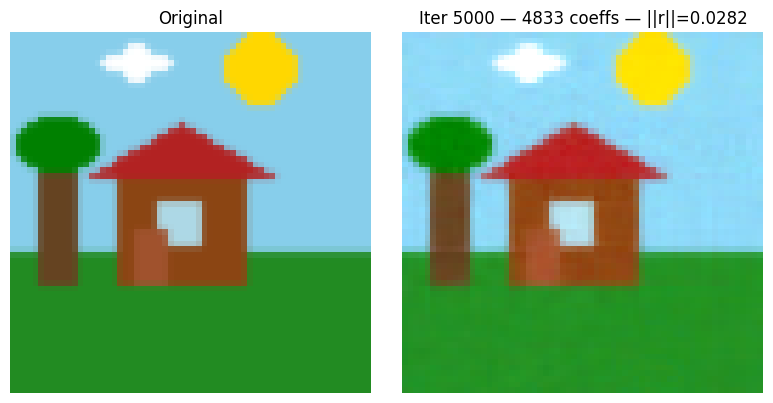

In [ ]:
def compute_psnr(original: np.ndarray, reconstructed: np.ndarray, max_val: float = 1.0) -> float:
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float("inf")
    return float(10 * np.log10(max_val ** 2 / mse))


class IterativeReconstructor:
    """Run T-NET at successive iteration checkpoints and display 3-D RGB snapshots."""

    def __init__(self, factor_matrices, Y, checkpoints, model_class=TNET, **kwargs):
        self.factor_matrices = factor_matrices
        self.Y = Y
        self.checkpoints = sorted(checkpoints)
        self.model_class = model_class
        self.kwargs = kwargs
        self.snapshots: List[dict] = []

    def run(self, live_display: bool = True) -> List[dict]:
        self.snapshots.clear()
        for n_iter in self.checkpoints:
            model = self.model_class(iterations=n_iter, tolerance=1e-15, debug_mode=True, **self.kwargs)
            model.fit(self.factor_matrices, self.Y)
            Y_hat = np.clip(np.array(model.predict(self.factor_matrices)), 0, 1)
            snap = {
                "iter": model.n_iter_,
                "n_active": len(model.active_columns_),
                "residual_norm": float(model.norm_r_[-1]),
                "image": Y_hat,
            }
            self.snapshots.append(snap)
            print(f"[checkpoint] iter={model.n_iter_:>4d}  |  active={snap['n_active']:>4d}  |  ||r||={snap['residual_norm']:.6f}")
            if live_display:
                ipy_display.clear_output(wait=True)
                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(self.Y); axes[0].set_title("Original"); axes[0].axis("off")
                axes[1].imshow(Y_hat)
                axes[1].set_title(f"Iter {model.n_iter_} — {snap['n_active']} coeffs — ||r||={snap['residual_norm']:.4f}")
                axes[1].axis("off")
                plt.tight_layout(); plt.show()
        return self.snapshots


LAMBDA2 = 0.1
# Fewer checkpoints to lower memory and runtime while preserving trend visibility.
checkpoints = [1, 10, 50, 250, 1000, 2500, 5000]

reconstructor = IterativeReconstructor(
    factor_matrices=[D1, D2, D3],
    Y=Y_image,
    checkpoints=checkpoints,
    lambda2=LAMBDA2,
)
snapshots = reconstructor.run(live_display=True)

### Snapshot Gallery

In [ ]:
n_snaps = len(snapshots)
cols = min(n_snaps, 6)
rows = (n_snaps + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
axes_flat = np.array(axes).flatten() if n_snaps > 1 else [axes]

for ax, snap in zip(axes_flat, snapshots):
    ax.imshow(snap["image"])
    ax.set_title(f"iter {snap['iter']}\n{snap['n_active']} coeffs", fontsize=8)
    ax.axis("off")
for ax in axes_flat[n_snaps:]:
    ax.axis("off")

fig.suptitle(f"T-NET 3-D Reconstruction Progression  (λ₂={LAMBDA2})", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Convergence and Quality Metrics

In [ ]:
iters   = [s["iter"] for s in snapshots]
resids  = [s["residual_norm"] for s in snapshots]
actives = [s["n_active"] for s in snapshots]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(iters, resids, "o-", color="steelblue", linewidth=2)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Residual Norm ||r||")
ax1.set_title(f"T-NET Convergence  (λ₂={LAMBDA2})")
ax1.grid(True, which="both", linewidth=0.3)

ax2.plot(iters, actives, "s-", color="darkorange", linewidth=2)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Active Coefficients")
ax2.set_title(f"T-NET Sparsity vs Iteration  (λ₂={LAMBDA2})")
ax2.grid(True, linewidth=0.3)

plt.tight_layout()
plt.show()

final = snapshots[-1]
mse_val  = float(np.mean((Y_image - final["image"]) ** 2))
psnr_val = compute_psnr(Y_image, final["image"])

print("┌──────────────────────────────────────────┐")
print(f"│ lambda2                 : {LAMBDA2:>13.3f}  │")
print(f"│ Final iteration         : {final['iter']:>10d}     │")
print(f"│ Active coefficients     : {final['n_active']:>10d}     │")
print(f"│ Total dictionary atoms  : {total_atoms:>10,}     │")
print(f"│ Sparsity ratio          : {final['n_active'] / total_atoms:>10.2%}     │")
print(f"│ Residual norm           : {final['residual_norm']:>13.6f}  │")
print(f"│ MSE                     : {mse_val:>13.6e}  │")
print(f"│ PSNR                    : {psnr_val:>10.2f} dB   │")
print("└──────────────────────────────────────────┘")

## 7. Final Reconstruction vs Original

In [ ]:
def compare_images(original, reconstructed, title="Reconstruction Comparison"):
    reconstructed = np.clip(reconstructed, 0, 1)
    error = np.abs(original - reconstructed)
    mse   = float(np.mean((original - reconstructed) ** 2))
    psnr  = compute_psnr(original, reconstructed)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(original);       axes[0].set_title("Original");          axes[0].axis("off")
    axes[1].imshow(reconstructed);  axes[1].set_title("Reconstructed");     axes[1].axis("off")
    error_mag = np.mean(error, axis=2)
    im = axes[2].imshow(error_mag, cmap="hot", vmin=0, vmax=error_mag.max() or 1e-8)
    axes[2].set_title("Mean Absolute Error"); axes[2].axis("off")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f"  MSE      = {mse:.6e}")
    print(f"  PSNR     = {psnr:.2f} dB")
    print(f"  Max |err|= {error.max():.6e}")


compare_images(Y_image, snapshots[-1]["image"], title=f"T-NET Reconstruction (λ₂={LAMBDA2})")

## 8. Effect of `lambda2` on Reconstruction Quality

We sweep `lambda2` over several values and compare PSNR, sparsity, and residual norm.
A larger `lambda2` applies stronger L2 shrinkage — typically fewer active coefficients
but potentially smoother (less noisy) reconstructions.

In [ ]:
lambda2_values = [0.01, 0.1, 0.5, 1.0, 2.0]
N_ITER = 2000
TOL    = 0.05

lambda2_results = {}
for lam in lambda2_values:
    model = TNET(iterations=N_ITER, tolerance=TOL, lambda2=lam, debug_mode=True)
    t0 = time.perf_counter()
    model.fit([D1, D2, D3], Y_image)
    elapsed = time.perf_counter() - t0
    Y_hat = np.clip(np.array(model.predict([D1, D2, D3])), 0, 1)
    lambda2_results[lam] = {
        "n_iter":   model.n_iter_,
        "n_active": len(model.active_columns_),
        "residual": float(model.norm_r_[-1]),
        "psnr":     compute_psnr(Y_image, Y_hat),
        "time":     elapsed,
        "image":    Y_hat,
    }
    print(f"λ₂={lam:>5.2f}  iters={model.n_iter_:>4d}  active={len(model.active_columns_):>4d}  "
          f"PSNR={lambda2_results[lam]['psnr']:.2f} dB  {elapsed:.2f}s")

In [ ]:
# --- Reconstructed images across lambda2 values ---
n_lam = len(lambda2_values)
fig, axes = plt.subplots(2, n_lam + 1, figsize=((n_lam + 1) * 2.8, 6))

# Column 0: original
axes[0, 0].imshow(Y_image); axes[0, 0].set_title("Original", fontsize=9); axes[0, 0].axis("off")
axes[1, 0].axis("off")

for col, lam in enumerate(lambda2_values, start=1):
    r = lambda2_results[lam]
    axes[0, col].imshow(r["image"])
    axes[0, col].set_title(f"λ₂={lam}\nPSNR={r['psnr']:.1f} dB", fontsize=8)
    axes[0, col].axis("off")

    err = np.mean(np.abs(Y_image - r["image"]), axis=2)
    axes[1, col].imshow(err, cmap="hot", vmin=0, vmax=0.15)
    axes[1, col].set_title(f"{r['n_active']} coeffs", fontsize=8)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Reconstruction", fontsize=9)
axes[1, 0].set_ylabel("Mean |error|",    fontsize=9)
fig.suptitle("T-NET: Effect of λ₂ on Reconstruction", fontsize=13)
plt.tight_layout()
plt.show()

# --- PSNR and sparsity vs lambda2 ---
lams    = lambda2_values
psnrs   = [lambda2_results[l]["psnr"]     for l in lams]
actives = [lambda2_results[l]["n_active"] for l in lams]
resids  = [lambda2_results[l]["residual"] for l in lams]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(lams, psnrs, "o-", color="steelblue",   linewidth=2, markersize=7)
axes[0].set_xlabel("λ₂"); axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("Reconstruction Quality vs λ₂")
axes[0].grid(True, linewidth=0.3)

axes[1].plot(lams, actives, "s-", color="darkorange", linewidth=2, markersize=7)
axes[1].set_xlabel("λ₂"); axes[1].set_ylabel("Active Coefficients")
axes[1].set_title("Sparsity vs λ₂")
axes[1].grid(True, linewidth=0.3)

axes[2].semilogy(lams, resids, "^-", color="crimson", linewidth=2, markersize=7)
axes[2].set_xlabel("λ₂"); axes[2].set_ylabel("Final ||r||")
axes[2].set_title("Residual Norm vs λ₂")
axes[2].grid(True, which="both", linewidth=0.3)

plt.tight_layout()
plt.show()

## 9. T-NET vs T-LARS Side-by-Side

Direct comparison of T-NET (`lambda2=0.1`) vs T-LARS (`lambda2=0`, pure L1) on the same image,
same iteration budget, and both L1 and L0 modes.

In [ ]:
N_ITER_CMP = 2000
TOL_CMP    = 0.05

compare_configs = [
    ("T-LARS  L1", TLARS, dict(l0_mode=False)),
    ("T-LARS  L0", TLARS, dict(l0_mode=True)),
    ("T-NET   L1  λ₂=0.1", TNET,  dict(l0_mode=False, lambda2=0.1)),
    ("T-NET   L1  λ₂=0.5", TNET,  dict(l0_mode=False, lambda2=0.5)),
    ("T-NET   L0  λ₂=0.1", TNET,  dict(l0_mode=True,  lambda2=0.1)),
]

cmp_results = {}
for label, cls, kwargs in compare_configs:
    model = cls(iterations=N_ITER_CMP, tolerance=TOL_CMP, debug_mode=True, **kwargs)
    t0 = time.perf_counter()
    model.fit([D1, D2, D3], Y_image)
    elapsed = time.perf_counter() - t0
    Y_hat = np.clip(np.array(model.predict([D1, D2, D3])), 0, 1)
    cmp_results[label] = {
        "n_iter":   model.n_iter_,
        "n_active": len(model.active_columns_),
        "residual": float(model.norm_r_[-1]),
        "psnr":     compute_psnr(Y_image, Y_hat),
        "time":     elapsed,
        "image":    Y_hat,
    }
    r = cmp_results[label]
    print(f"{label:>24s}  →  {r['n_iter']:>4d} iters  {r['n_active']:>4d} coeffs  "
          f"PSNR={r['psnr']:.2f} dB  {elapsed:.2f}s")

In [ ]:
# --- Image comparison grid ---
labels_cmp = list(cmp_results.keys())
n_cmp = len(labels_cmp)

fig, axes = plt.subplots(2, n_cmp + 1, figsize=((n_cmp + 1) * 2.8, 6))

axes[0, 0].imshow(Y_image); axes[0, 0].set_title("Original", fontsize=9); axes[0, 0].axis("off")
axes[1, 0].axis("off")

for col, label in enumerate(labels_cmp, start=1):
    r = cmp_results[label]
    axes[0, col].imshow(r["image"])
    axes[0, col].set_title(f"{label}\nPSNR={r['psnr']:.1f} dB", fontsize=7)
    axes[0, col].axis("off")
    err = np.mean(np.abs(Y_image - r["image"]), axis=2)
    axes[1, col].imshow(err, cmap="hot", vmin=0, vmax=0.15)
    axes[1, col].set_title(f"{r['n_active']} coeffs", fontsize=8)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Reconstruction", fontsize=9)
axes[1, 0].set_ylabel("Mean |error|",    fontsize=9)
fig.suptitle("T-LARS vs T-NET Comparison", fontsize=13)
plt.tight_layout()
plt.show()

# --- Bar chart comparison ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
short_labels = [l.strip() for l in labels_cmp]
colors = ["steelblue", "cornflowerblue", "darkorange", "tomato", "gold"]

bars1 = ax1.bar(range(n_cmp), [cmp_results[l]["psnr"]     for l in labels_cmp], color=colors)
ax1.set_xticks(range(n_cmp)); ax1.set_xticklabels(short_labels, rotation=20, ha="right", fontsize=8)
ax1.set_ylabel("PSNR (dB)"); ax1.set_title("Reconstruction Quality")
for bar, l in zip(bars1, labels_cmp):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{cmp_results[l]['psnr']:.1f}", ha="center", fontsize=8)

bars2 = ax2.bar(range(n_cmp), [cmp_results[l]["n_active"] for l in labels_cmp], color=colors)
ax2.set_xticks(range(n_cmp)); ax2.set_xticklabels(short_labels, rotation=20, ha="right", fontsize=8)
ax2.set_ylabel("Active Coefficients"); ax2.set_title("Sparsity")
for bar, l in zip(bars2, labels_cmp):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(cmp_results[l]["n_active"]), ha="center", fontsize=8)

plt.suptitle("T-LARS vs T-NET", fontsize=13)
plt.tight_layout()
plt.show()

## 10. T-NET for Image Denoising

The L2 penalty makes T-NET a natural denoiser — we set the stopping tolerance
to the noise level so the algorithm stops when the residual matches the noise floor.

In [ ]:
rng = np.random.default_rng(42)
noise_level = 0.10
Y_noisy = np.clip(Y_image + rng.normal(0, noise_level, Y_image.shape), 0, 1)

# T-LARS denoising (baseline)
model_tlars_dn = TLARS(iterations=2000, tolerance=noise_level, debug_mode=True)
model_tlars_dn.fit([D1, D2, D3], Y_noisy)
Y_tlars_dn = np.clip(np.array(model_tlars_dn.predict([D1, D2, D3])), 0, 1)

# T-NET denoising (lambda2=0.5 — stronger L2 shrinkage for denoising)
model_tnet_dn = TNET(iterations=2000, tolerance=noise_level, lambda2=0.5, debug_mode=True)
model_tnet_dn.fit([D1, D2, D3], Y_noisy)
Y_tnet_dn = np.clip(np.array(model_tnet_dn.predict([D1, D2, D3])), 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
images = [Y_image, Y_noisy, Y_tlars_dn, Y_tnet_dn]
titles = [
    "Original (clean)",
    f"Noisy (σ={noise_level})",
    f"T-LARS denoised\n({len(model_tlars_dn.active_columns_)} coeffs)",
    f"T-NET denoised  λ₂=0.5\n({len(model_tnet_dn.active_columns_)} coeffs)",
]
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis("off")

plt.suptitle("T-NET vs T-LARS — Image Denoising", fontsize=13)
plt.tight_layout()
plt.show()

psnr_noisy   = compute_psnr(Y_image, Y_noisy)
psnr_tlars   = compute_psnr(Y_image, Y_tlars_dn)
psnr_tnet    = compute_psnr(Y_image, Y_tnet_dn)

print(f"  PSNR (noisy input)       : {psnr_noisy:.2f} dB")
print(f"  PSNR (T-LARS denoised)   : {psnr_tlars:.2f} dB  (+{psnr_tlars - psnr_noisy:+.2f} dB)")
print(f"  PSNR (T-NET  denoised)   : {psnr_tnet:.2f} dB  (+{psnr_tnet  - psnr_noisy:+.2f} dB)")

## 11. Parameter Introspection

In [ ]:
model = TNET(tolerance=0.05, lambda2=0.3, l0_mode=False, iterations=500)

print("get_params():")
for k, v in model.get_params().items():
    print(f"  {k:>22s} = {v!r}")

model.set_params(lambda2=1.0, tolerance=0.01)
print(f"\nAfter set_params(lambda2=1.0, tolerance=0.01):")
print(f"  lambda2   = {model.config.lambda2}")
print(f"  tolerance = {model.config.tolerance}")
print(f"  repr      = {model!r}")